<a href="https://colab.research.google.com/github/SergeiVKalinin/Probabilistic-Unmixing-0/blob/main/notebooks/00_Quick_Start_and_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 00 — Quick Start: Generate and Inspect the Common Dataset

This notebook introduces the data model used throughout **Probabilistic Unmixing 0**.

The package assumes linear spectral mixing:

$$Y_i(E) = \sum_k W_{ik} S_k(E) + \epsilon_i(E)$$

For the current version, **composition and mixture fraction are the same quantity**. A single `UnmixingData` object contains the measured spectra, concentration information, measurement uncertainty, and any available spectral knowledge.

The same object can be produced in two ways:

- `pu.generate_example(...)` for controlled synthetic data;
- `pu.from_arrays(...)` for experimental data.

The purpose of this notebook is only to understand the data object. Inference is introduced in the next notebooks.

In [1]:
!pip install -q --force-reinstall --no-deps git+https://github.com/SergeiVKalinin/Probabilistic-Unmixing-0.git

import numpy as np
import matplotlib.pyplot as plt
import probunmix as pu

print("probunmix version:", pu.__version__)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
probunmix version: 0.1.0


## Generate one benchmark dataset

The generator creates one physical mixture experiment together with all information needed to demonstrate Levels 0, 1, and 2. Synthetic truth is included only so that later notebooks can evaluate recovery.

In [2]:
data = pu.generate_example(
    n_locations=60,
    n_channels=160,
    n_library=100,
    seed=42,
)

pu.validate_data(data)
pu.print_data_summary(data)

Probabilistic Unmixing Dataset

Dimensions
----------
Locations:          60
Spectral channels:  160
Components:         4

Spectral data
-------------
Spectral axis:      0 to 12
Measured intensity: -0.0157 to 0.9109

Composition / mixture fractions
-------------------------------
Row-sum range:      1.000000 to 1.000000
Mean row sum:       1.000000

Available spectral knowledge
----------------------------
Level 0 fixed spectra:      YES
Level 1 parametric prior:   YES
Level 2 functional library: YES

Evaluation information
----------------------
Synthetic truth:            YES


## Inspect the array shapes

`N` is the number of measurement locations, `M` the number of spectral channels, and `K` the number of components.

- `Y` has shape `(N, M)`.
- `W_mean` and `W_sigma` have shape `(N, K)`.
- `S_fixed` has shape `(K, M)`.
- `S_library` has shape `(K, R, M)` where `R` is the number of Level 2 library spectra per component.

In [3]:
print("E:", data.E.shape)
print("Y:", data.Y.shape)
print("sigma_y:", np.asarray(data.sigma_y).shape)
print("W_mean:", data.W_mean.shape)
print("W_sigma:", data.W_sigma.shape)
print("S_fixed:", data.S_fixed.shape)
print("theta_mean:", data.theta_mean.shape)
print("theta_sigma:", data.theta_sigma.shape)
print("S_library:", data.S_library.shape)

print()
print("Synthetic truth:")
print("W_true:", data.W_true.shape)
print("S_true:", data.S_true.shape)
print("Y_clean:", data.Y_clean.shape)

E: (160,)
Y: (60, 160)
sigma_y: (60, 160)
W_mean: (60, 4)
W_sigma: (60, 4)
S_fixed: (4, 160)
theta_mean: (4, 5)
theta_sigma: (4, 5)
S_library: (4, 100, 160)

Synthetic truth:
W_true: (60, 4)
S_true: (4, 160)
Y_clean: (60, 160)


## Visualize the dataset

The input report shows representative measured spectra, the measured concentration/fraction information, and the attached spectral knowledge.

In a real experimental analysis, the hidden truth arrays would simply be absent.

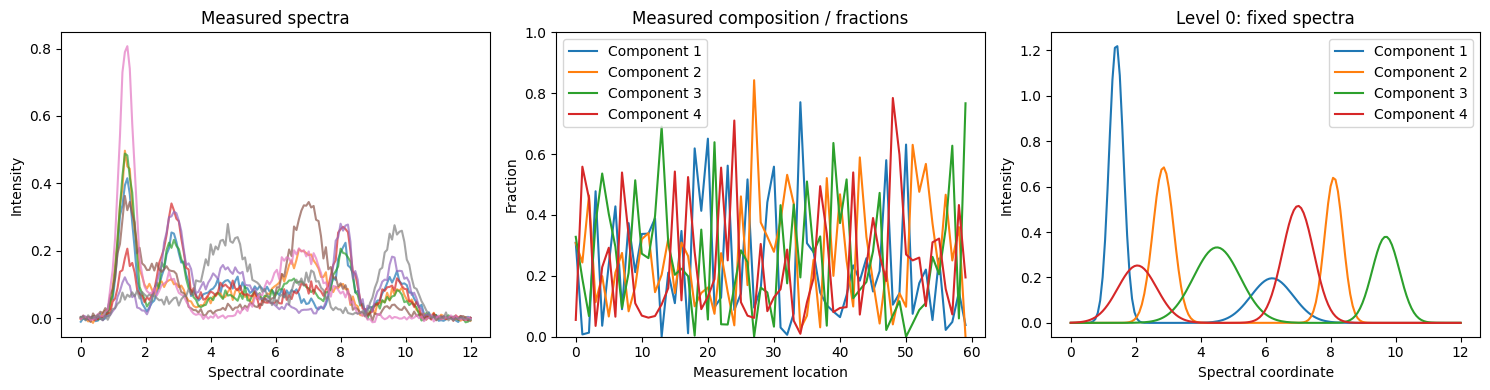

In [4]:
pu.plot_data(data);

## What changes between Levels 0, 1, and 2?

The measured experiment does **not** change.

- **Level 0:** the endmember spectra are treated as exact.
- **Level 1:** the endmember spectra have a parametric form with uncertain parameters.
- **Level 2:** prior spectral knowledge is an ensemble of plausible complete spectra.

This separation is the central design principle of the package.